# DS2 — Proefexamen (Vraag-per-vraag stijl)

**Belangrijk:**
- Gebruik géén `for`-loops of `while`-loops voor dataverwerking; werk vectorized met **NumPy** en **pandas**.
- Splits bij ML altijd in **X** (2D) en **y** (1D) waar van toepassing.
- Gebruik bij classificatie **stratify** als het kan bij train/test split.
- Rapporteer steeds de gevraagde metrics (R², MAE/RMSE, accuracy, precision/recall/F1) waar relevant.
- Zorg voor nette figuren (titels, assenlabels) en sla ze op indien gevraagd.

> Tip: Gebruik een vaste `random_state` of `seed` waar van toepassing.


### 0. Imports

In [2]:
#SOLUTION_START
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, classification_report, ConfusionMatrixDisplay, root_mean_squared_error
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from tensorflow.keras import Model  
from tensorflow.keras.layers import Input, Dense  
from tensorflow.keras.optimizers import Adam

from simanneal import Annealer

#SOLUTION_END


## Vraag 1 — NumPy basis (8p)

**Context.** Maak een 2D-array met vorm (4, 3) met een vaste `seed`. Beantwoord volgende subvraagjes zonder loops.

a) Toon `shape`, `dtype` en de middelste kolom als 1D-array. *(2p)*  
b) Geef element-wise som en product van `a=[1,2,3,4]` en `b=[10,20,30,40]`. *(2p)*  
c) Maak een boolean-mask voor `a*10 == b` en toon het resultaat. *(2p)*  
d) Leg in 1 zin uit wat broadcasting is (in code comment). *(2p)*


In [2]:
# a
#SOLUTION_START
rng = np.random.default_rng(42)
arr = rng.random((4,3))
print(arr.shape)
print(arr.dtype)
print(arr[:,1])
#SOLUTION_END


(4, 3)
float64
[0.43887844 0.09417735 0.78606431 0.37079802]


In [3]:
# b
#SOLUTION_START
a = np.array([1,2,3,4])
b = np.array([10,20,30,40])
som = a + b
prod = a * b
print(som, prod)
#SOLUTION_END


[11 22 33 44] [ 10  40  90 160]


In [4]:
# c
#SOLUTION_START
mask = (a*10) == b
print(mask)
#SOLUTION_END


[ True  True  True  True]


In [ ]:
# d (uitleg in comment)
#SOLUTION_START
# Broadcasting uitleg: --> is berekeningen doen op arrays met verschillende shapes
#SOLUTION_END


## Vraag 2 — pandas indexing: `.loc` vs `.iloc` (10p)

In [5]:
# Context-DF
#SOLUTION_START
df = pd.DataFrame({
    'naam': ['Anna','Bob','Charlie','Diana'],
    'leeftijd': [25,30,35,28],
    'stad': ['Amsterdam','Rotterdam','Utrecht','Den Haag']
}, index=[10,11,12,13])
df
#SOLUTION_END


,naam,leeftijd,stad
10,Anna,25,Amsterdam
11,Bob,30,Rotterdam
12,Charlie,35,Utrecht
13,Diana,28,Den Haag


a) Haal **Anna’s leeftijd** op via `.iloc` én via `.loc`. *(3p)*  
b) Selecteer rijen **index 10 t/m 12** via `.loc` en toon het slicing-verschil met `.iloc`. *(3p)*  
c) Sorteer op `leeftijd` en illustreer waarom `df_sorted.iloc[0]` en `df_sorted.loc[0]` verschillend kunnen zijn. *(4p)*


In [6]:
# a
#SOLUTION_START
print(df.loc[10, "leeftijd"])
print(df.iloc[0, 1])
#SOLUTION_END


25
25


In [9]:
# b
#SOLUTION_START
print(df.loc[10:12])
print("Hieronder is het met de iloc")
print(df.iloc[10:12])
#SOLUTION_END


       naam  leeftijd       stad
10     Anna        25  Amsterdam
11      Bob        30  Rotterdam
12  Charlie        35    Utrecht
Hieronder is het met de iloc
Empty DataFrame
Columns: [naam, leeftijd, stad]
Index: []


In [ ]:
# c
#SOLUTION_START
df_sorted = df.sort_values("leeftijd")
print("Eerste rij met iloc[0]:")s
print(df_sorted.iloc[0])   # eerste rij NA sorteren

print("\nRij met loc[0]:")
try:
    print(df_sorted.loc[0])  # probeert label 0 te vinden
except KeyError as e:
    print("KeyError:", e)
#SOLUTION_END


Eerste rij met iloc[0]:
naam             Anna
leeftijd           25
stad        Amsterdam
Name: 10, dtype: object

Rij met loc[0]:
KeyError: 0


## Vraag 3 — Cleaning & strings (10p)

In [12]:
# Context-DF
#SOLUTION_START
data = pd.DataFrame({
    'Raw': ['  Alice  ', 'BOB', None, 'Di(a)na', 'Ch_ar-lie '],
    'Age': [25, 30, None, 28, 35]
})
data
#SOLUTION_END


,Raw,Age
0,Alice,25.0
1,BOB,30.0
2,None,NaN
3,Di(a)na,28.0
4,Ch_ar-lie,35.0


a) Trim whitespace in `Raw`, maak Title Case, verwijder `()_-` en hernoem kolom naar `Name`. *(4p)*  
b) Imputeer ontbrekende `Age` met het gemiddelde. Toon aantal NaN’s voor/na. *(3p)*  
c) Geef frequenties én relatieve frequenties van de **eerste letter** van `Name`. *(3p)*


In [18]:
# a
#SOLUTION_START

data["Name"] = ( data["Raw"].str.strip().str.title().str.replace(r"[()_-]", "", regex=True)) 
print(data)
#SOLUTION_END


          Raw   Age     Name
0     Alice    25.0    Alice
1         BOB  30.0      Bob
2        None   NaN     None
3     Di(a)na  28.0    DiANa
4  Ch_ar-lie   35.0  ChArLie


In [ ]:
# b
#SOLUTION_START

print("Aantal NaN's voor de deletion: ", data["Age"].isna().sum())

average = data["Age"].mean()
data["Age"].fillna(average, inplace=True)

print("Aantal NaN's na de deletion: ", data["Age"].isna().sum())
print(data)
#SOLUTION_END

#EXTRA drop NaN values? 
data = data.dropna()

#of alleen rijen droppen waar Age leeg is?
data = data.dropna(subset=["Age"])


Aantal NaN's voor de deletion:  0
Aantal NaN's na de deletion:  0
          Raw   Age     Name
0     Alice    25.0    Alice
1         BOB  30.0      Bob
2        None  29.5     None
3     Di(a)na  28.0    DiANa
4  Ch_ar-lie   35.0  ChArLie


/var/folders/4n/z403ds5x0n141m695xdfdlcm0000gn/T/ipykernel_1569/1665422607.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(average, inplace=True)


In [ ]:
# c
#SOLUTION_START

eerste_letter_count = data["Name"].str[0]

print("Absolute frequenties: ") #hoeveel keer komt het voor
print(eerste_letter_count.value_counts())

print("Relatieve frequenties: ") #wat is het aandeel in % van dit 
print(eerste_letter_count.value_counts(normalize=True))
#SOLUTION_END


Absolute frequenties: 
Name
A    1
B    1
D    1
C    1
Name: count, dtype: int64
Relatieve frequenties: 
Name
A    0.25
B    0.25
D    0.25
C    0.25
Name: proportion, dtype: float64


## Vraag 4 — GroupBy & transform (8p)

Gebruik (indien beschikbaar) `airlines.csv` met kolommen zoals `Gender`, `Age`, `Airport Continent`.  
a) Bereken het gemiddelde Horsepower per Brand en het aantal auto’s per FuelType. *(4p)*  
b) Maak Horsepower_Z_by_Brand = z-score van Horsepower per Brand met groupby(...).transform(...). Toon de eerste 5 rijen. *(4p)*


In [9]:
# a
#SOLUTION_START
cars = pd.read_csv('Cars.csv', delimiter=";", decimal=".")

print("Gemiddelde Horsepower per Brand:")
print(cars.groupby("Manufacturer")["Horsepower"].mean().sort_values())

print("\nAantal auto’s per FuelType:")
print(cars["Type"].value_counts())
#SOLUTION_END


Gemiddelde Horsepower per Brand:
Manufacturer
Suzuki            70.000000
Geo               72.500000
Saturn            85.000000
Plymouth          92.000000
Subaru            97.666667
Hyundai          106.250000
Mercury          120.000000
Toyota           121.250000
Ford             122.625000
Volkswagen       125.500000
Honda            134.000000
Dodge            137.833333
Saab             140.000000
Volvo            141.000000
Nissan           142.750000
Pontiac          142.800000
Chrysler         147.000000
Mitsubishi       147.000000
Oldsmobile       151.250000
Mazda            151.800000
Eagle            153.000000
Buick            157.500000
Chevrolet        161.875000
Acura            170.000000
Audi             172.000000
Mercedes-Benz    173.500000
Lincoln          185.000000
Lexus            205.000000
BMW              208.000000
Cadillac         247.500000
Infiniti         278.000000
Name: Horsepower, dtype: float64

Aantal auto’s per FuelType:
Type
Midsize    22
Small

In [12]:
# b
#SOLUTION_START

cars["HorsePower_Z_by_brand"] = (
    cars.groupby("Manufacturer")["Horsepower"].transform(lambda x: (x - x.mean()) / x.std())
)

print(cars[["Manufacturer", "Horsepower", "HorsePower_Z_by_brand"]].head())
#SOLUTION_END


  Manufacturer  Horsepower  HorsePower_Z_by_brand
0        Acura         140              -0.707107
1        Acura         200               0.707107
2         Audi         172                    NaN
3         Audi         172                    NaN
4          BMW         208                    NaN


## Vraag 5 — Matplotlib (6p)

Maak een scatterplot van Horsepower t.o.v. een andere numerieke kolom uit Cars.csv (bijv. Weight of MPG).
Voorzie titel en assenlabels. Sla op als scatter.png. (6p)

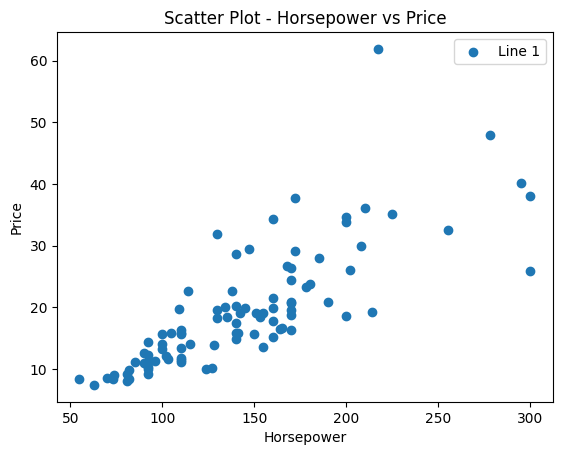

In [ ]:
#SOLUTION_START
paardenkracht = cars["Horsepower"]
prijs = cars["Price"]

plt.figure()
plt.scatter(paardenkracht, prijs, marker='o', label='Line 1') #label wordt enkel gebruikt als je een legende hebt
plt.legend()
plt.title('Scatter Plot - Horsepower vs Price')
plt.xlabel('Horsepower'); plt.ylabel('Price')
plt.savefig('scatter.png', dpi=150, bbox_inches='tight')
#SOLUTION_END


## Vraag 6 — ML-pipeline (train/test + scaling) (10p)

 a) *(4p)*
Stel **X** (kies 2–3 numerieke kolommen, bv. `Horsepower`, `Weight`, `MPG`) en **y** (één target, bv. `FuelType` of `Manufacturer`) op.  
**Split** de data in train en test met `train_size=0.8`.  
Indien `y` een classificatievariabele is, gebruik `stratify=y`.  
*Schrijf in één zin waarom `stratify` nuttig is.*

b) Normaliseer features met `StandardScaler` of `MinMaxScaler`. Toon de vorm van `X_train` vóór en na scaling. *(6p)*


In [19]:
# a
#SOLUTION_START
X = cars[['Horsepower', 'Weight', 'MPG.city']]
y = cars['Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y)
# Opmerking (comment): stratify zorgt ervoor dat de klasseverdeling in train en test ongeveer gelijk blijft, waardoor evaluatie gelijker blijft 
#SOLUTION_END


In [20]:
# b
#SOLUTION_START
pipe = Pipeline([('scaler', StandardScaler())])
X_train_sc = pipe.fit_transform(X_train)
X_test_sc  = pipe.transform(X_test)
print(X_train.shape, X_train_sc.shape)
#SOLUTION_END


(74, 3) (74, 3)


In [ ]:
# b (cursus versie)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Voor scaling:", X_train.shape, "| Na scaling:", X_train_sc.shape)

Voor scaling: (74, 3) | Na scaling: (74, 3)


<function print>

## Vraag 7 — Regressie (Linear & Polynomial) (10p)

 a) *(6p)*
Voer een **LinearRegression** uit met een gekozen numerieke target (bv. `Price`) en enkele numerieke features (bv. `Horsepower`, `Weight`, `MPG.city`).  
Rapporteer **R² (test)**, **MAE**, **RMSE** en toon **coëfficiënten en intercept**

b) *(4p)*
Voeg PolynomialFeatures(graad=2) toe in een Pipeline en vergelijk de R²(test) met (a) in 1–2 zinnen.

In [35]:
# a
#SOLUTION_START

X = cars[['Horsepower', 'Weight', 'MPG.city']]
y = cars['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0, shuffle=True)

model = LinearRegression()

model.fit(X_train, y_train)

print(f'Intercept: {model.intercept_}') 
print(f'Coefficient: {model.coef_}')

#berekeningen doen van de gevraagd values 
y_test_pred = model.predict(X_test)

mae = mean_absolute_error(y_true=y_test, y_pred=y_test_pred)
mse = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
mape = mean_absolute_error(y_true=y_test, y_pred=y_test_pred)
rmse = root_mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred) 

print(f'MAE= {mae:.3f} - MSE = {mse:.3f} - MAPE= {mape:.3f} - RMSE= = {rmse:.3f} - R^2= = {r2:.3f}')
#SOLUTION_END


Intercept: -4.38613522116562
Coefficient: [ 0.11947394  0.00258394 -0.05621725]
MAE= 3.033 - MSE = 17.449 - MAPE= 3.033 - RMSE= = 4.177 - R^2= = 0.760


In [41]:
# b
#SOLUTION_START

poly_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())

poly_model.fit(X_train, y_train)

y_test_pred = poly_model.predict(X_test)  
mse = mean_squared_error(y_true=y_test, y_pred=y_test_pred)  
r2 = r2_score(y_test, y_test_pred)  
print(f'MSE = {mse:.3f} - R^2= = {r2:.3f}')
#SOLUTION_END


MSE = 20.115 - R^2= = 0.723


## Vraag 8 — Classificatie (Decision Tree / Random Forest) (14p)

 a) DecisionTreeClassifier(max_depth=2) *(6p)*
Toon `get_params()`, accuracy op de test-set en het `classification_report`. Plot een confusion matrix.

 b) *(8p)*
**RandomForestClassifier(n_estimators=200, max_depth=5)**: rapporteer **accuracy** + `classification_report` en plot een **confusion matrix**. Vergelijk kort met de Decision Tree uit (a).

Params:  {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
Model classes: ['Compact' 'Large' 'Midsize' 'Small' 'Sporty' 'Van']
Accuracy (test): 0.526
Classification report:
               precision    recall  f1-score   support

     Compact       0.50      1.00      0.67         3
       Large       0.00      0.00      0.00         2
     Midsize       0.43      0.60      0.50         5
       Small       0.67      1.00      0.80         4
      Sporty       0.00      0.00      0.00         3
         Van       0.00      0.00      0.00         2

    accuracy                           0.53        19
   macro avg       0.27      0.43      0.33        19
weighted avg       0.33      0.53      0.41        19



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

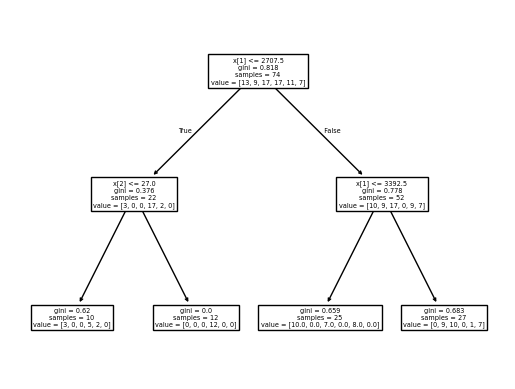

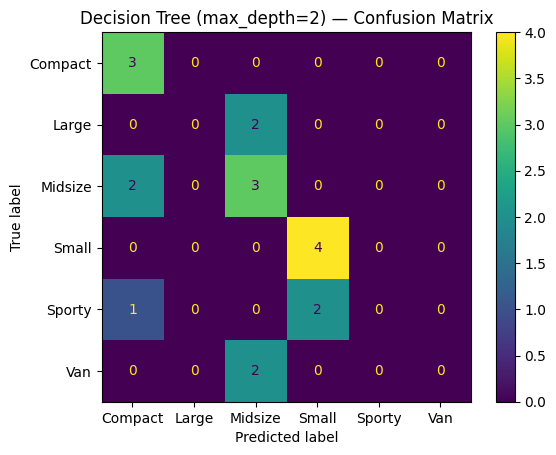

In [50]:
# a
#SOLUTION_START

#features + target
X = cars[["Horsepower", "Weight", "MPG.city"]]
y = cars["Type"]

#rijen met NaN droppen 
cars_nonan = pd.concat([X, y], axis=1).dropna()
X, y = cars_nonan[["Horsepower", "Weight", "MPG.city"]], cars_nonan["Type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,random_state=42 ,stratify=y) # Stratify is used so the classes for the tree are evenly spread as well

model = DecisionTreeClassifier(criterion='gini', max_depth=2, min_samples_split=5, random_state=42) # Deze opties zijn gewoon een voorbeeld, mogen weg BEHALVE gini
print("Params: ", model.get_params())
model.fit(X_train, y_train)

# Tonen van het model
print(f"Model classes: {model.classes_}")
plot_tree(model)

#metrics + confusion matrix
y_pred = model.predict(X_test)
print(f"Accuracy (test): {accuracy_score(y_test, y_pred):.3f}")
print("Classification report:\n", classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Decision Tree (max_depth=2) — Confusion Matrix")
plt.show()
#SOLUTION_END

RandomForest Accuracy (test): 0.526

Classification report (RF):
               precision    recall  f1-score   support

     Compact       0.50      1.00      0.67         3
       Large       0.25      0.50      0.33         2
     Midsize       0.00      0.00      0.00         5
       Small       0.67      1.00      0.80         4
      Sporty       0.00      0.00      0.00         3
         Van       0.67      1.00      0.80         2

    accuracy                           0.53        19
   macro avg       0.35      0.58      0.43        19
weighted avg       0.32      0.53      0.39        19



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

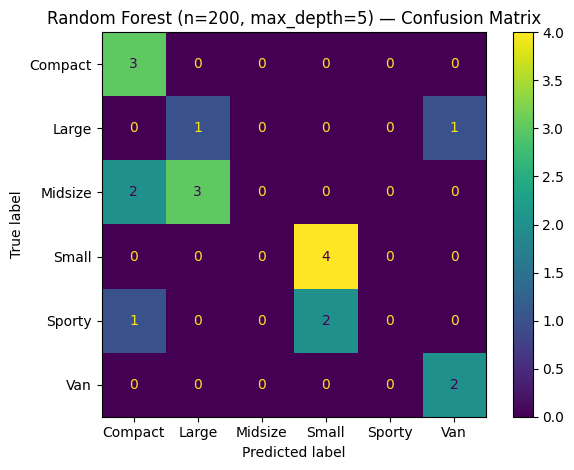

In [ ]:
# b
#SOLUTION_START
rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

#voorpellen en metrics geven 
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"RandomForest Accuracy (test): {acc_rf:.3f}")
print("\nClassification report (RF):\n", classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=rf.classes_)
plt.title("Random Forest (n=200, max_depth=5) — Confusion Matrix")
plt.tight_layout()
plt.show()

#SOLUTION_END

## Vraag 9 — Cross-Validation & Hyperparameter Tuning (8p)

a) Voer **5-fold cross-validation** uit (kies model passend bij je task) en print **gemiddelde** en **std** score. *(4p)*  
b) **GridSearchCV** voor `DecisionTreeClassifier` met `{'max_depth':[1,2,3,4,5,6],'criterion':['gini','entropy']}`. Print `best_params_` en `best_score_`. *(4p)*


In [52]:
# a
#SOLUTION_START

tree = DecisionTreeClassifier(random_state=42)

scores = cross_val_score(tree, X, y, cv=5)
print(f"Accuracy (5-fold): mean={scores.mean():.3f} | std={scores.std():.3f}")
print("Fold scores:", [round(s, 3) for s in scores])

#SOLUTION_END


Accuracy (5-fold): mean=0.452 | std=0.058
Fold scores: [0.474, 0.421, 0.421, 0.556, 0.389]


In [53]:
# b
#SOLUTION_START
param_grid = {
    "max_depth": [1, 2, 3, 4, 5, 6],
    "criterion": ["gini", "entropy"],
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,            # of cv=cv uit hierboven
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X, y)

print("best_params_ :", grid.best_params_)
print(f"best_score_  : {grid.best_score_:.3f}")
#SOLUTION_END


best_params_ : {'criterion': 'entropy', 'max_depth': 6}
best_score_  : 0.528


## Vraag 10 — K-Means Clustering (8p)

Gebruik 2–3 genormaliseerde numerieke features.  
a) Train **KMeans(n_clusters=3, random_state=42)**; toon `cluster_centers_` en eerste 10 labels. Plot een 2D-scatter met kleur=cluster en markeer centroids. *(5p)*  
b) Leg in 2–3 zinnen uit wat **`n_init`** doet en waarom het nuttig is. *(3p)*


Cluster centers (originele eenheden):
    Horsepower       Weight   MPG.city
0  108.204082  2609.693878  26.020408
1  159.000000  3576.833333  18.400000
2  236.000000  3614.285714  18.071429
Eerste 10 labels: [0 2 1 1 2 0 1 1 1 2]


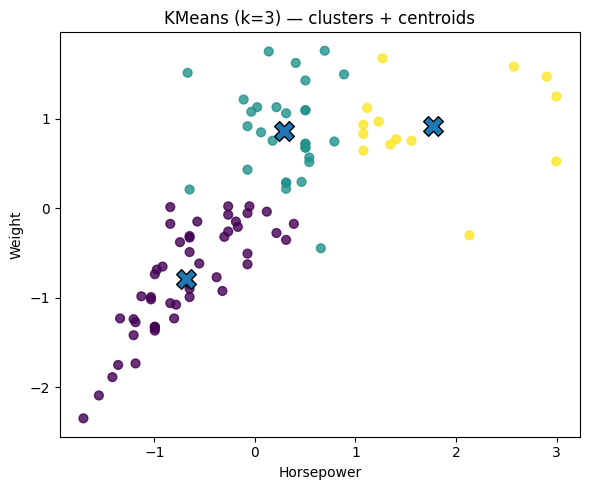

In [56]:
# a
#SOLUTION_START
X = cars[["Horsepower", "Weight", "MPG.city"]].dropna()

# 1) Normaliseren (belangrijk voor KMeans)
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# 2) KMeans
kmeans = KMeans(n_clusters=3, n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_sc)

# Centers in geschaalde ruimte + terug naar originele eenheden voor interpretatie
centers_sc = kmeans.cluster_centers_
centers_orig = scaler.inverse_transform(centers_sc)

print("Cluster centers (originele eenheden):\n", pd.DataFrame(centers_orig, columns=X.columns))
print("Eerste 10 labels:", labels[:10])
#SOLUTION_END

#OPTIONEEL: 2D scatter plot
x1, x2 = X_sc[:, 0], X_sc[:, 1]
c1, c2 = centers_sc[:, 0], centers_sc[:, 1]

plt.figure(figsize=(6,5))
plt.scatter(x1, x2, c=labels, s=40, alpha=0.8)
plt.scatter(c1, c2, s=200, marker="X", edgecolor="k")  # centroids
plt.xlabel(X.columns[0]); plt.ylabel(X.columns[1])
plt.title("KMeans (k=3) — clusters + centroids")
plt.tight_layout()
plt.show()


In [ ]:
# Uitleg n_init (kort):
# n_init is het aantal keer dat KMeans vanaf verschillende willekeurige starts wordt uitgevoerd;
# het beste resultaat (laagste inertia / SSE) wordt behouden. Dat is nuttig omdat KMeans
# in lokale minima kan vastlopen; meerdere initialisaties maken de oplossing robuuster
# (tegen een kleine extra rekentijd). n_init="auto" kiest hiervoor een veilige default (meerdere runs).

## Vraag 11 — Neurale Netten (theorie + mini-code) (8p)

a) Leg kort het verschil uit tussen **integratiefunctie** (gewogen som + bias) en **activatiefunctie** (`relu`, `sigmoid`, `softmax`). Wanneer gebruik je **softmax** en welke loss hoort daarbij? *(4p)*  
b) Schrijf pseudocode (of Keras-schets) voor (i) regressie (1 output, `linear` + MSE/MAE) en (ii) classificatie (softmax + categorical crossentropy). *(4p)*


**Integratie (pre-activatie)**  
- `z = w·x + b` → lineaire gewogen som + bias.

**Activatie (niet-lineariteit op z)**  
- **ReLU**: `max(0, z)` → standaard in hidden layers.  
- **Sigmoid**: 0–1 per output → binaire/multilabel.  
- **Softmax**: `exp(z_k)/Σ_j exp(z_j)` → kansverdeling (som = 1) over klassen.

**Wanneer softmax?**  
- In de **outputlaag** bij **multiclass** (exact één juiste klasse).

**Bijbehorende loss**  
- `categorical_crossentropy` (one-hot labels)  
- `sparse_categorical_crossentropy` (integer labels)


In [64]:
# b(i) — Regressie (Cars.csv): X/y + MinMaxScaler + train/test + Keras model
#SOLUTION_START

# 1) Data selecteren + NaN’s droppen
df = cars[["Horsepower", "Weight", "MPG.city", "Price"]].dropna()

X = df[["Horsepower", "Weight", "MPG.city"]].values
y = df["Price"].values

# 2) Splitten
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, shuffle=True
)

# 3) Schalen (Cheatsheet: MinMax)
scaler = MinMaxScaler()
x_train = scaler.fit_transform(X_train)
x_test  = scaler.transform(X_test)

# 4) Keras-schets (linear + MSE/MAE)
inputs = Input(shape=(x_train.shape[1],))
x = Dense(128, activation='relu')(inputs)
x = Dense(64,  activation='relu')(x)
outputs = Dense(1, activation='linear')(x)

reg_model = Model(inputs, outputs, name="NN_Reg")
reg_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

reg_model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.1)
reg_model.evaluate(x_test, y_test)
#SOLUTION_END

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 447.6713 - mae: 19.0409 - val_loss: 385.5196 - val_mae: 18.0820
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 469.2429 - mae: 19.4299 - val_loss: 380.7219 - val_mae: 17.9547
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 460.0153 - mae: 19.4145 - val_loss: 375.7991 - val_mae: 17.8237
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 481.0281 - mae: 19.5064 - val_loss: 370.7396 - val_mae: 17.6882
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 449.3994 - mae: 18.8446 - val_loss: 365.5457 - val_mae: 17.5475
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 468.3153 - mae: 19.1877 - val_loss: 359.9653 - val_mae: 17.3954
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 406.9210 - mae: 17.9661 - val_loss: 354.0344 - val_mae: 17.2316
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 441.0407 - mae: 18.5214 - val_loss: 347.5809 - val_mae: 17.0509
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━

[39.98595428466797, 5.529593467712402]

## Vraag 12 — Meta-heuristiek: Simulated Annealing (8p)

# Simulated Annealing Oefenopgave: Optimale Rugzak Probleem

## Achtergrond
Je bent een avonturier die zich voorbereidt op een expeditie. Je hebt een rugzak met beperkte capaciteit en moet kiezen welke items je meeneemt om je overlevingskansen te maximaliseren, terwijl je binnen het gewichtslimiet blijft.

## Gegevens
Je hebt 12 verschillende items beschikbaar:

```python
import numpy as np
from simanneal import Annealer

# Item eigenschappen
gewicht = np.array([5, 8, 3, 12, 7, 4, 9, 6, 2, 10, 8, 3])  # kg
waarde = np.array([60, 100, 20, 160, 80, 30, 120, 70, 15, 140, 90, 25])  # overlevingspunten
item_namen = ['Water fles', 'Tent', 'Kompas', 'Slaapzak', 'Mes', 'EHBO kit', 
              'Zaklamp', 'Touw', 'Lucifers', 'Kookpan', 'Warme kleren', 'Kaart']
```

## Opdracht
Implementeer een `RugzakProbleem` klasse die erft van `Annealer` om de optimale combinatie van items te vinden.

### Constraints:
- **Maximaal gewicht**: 35 kg
- **Doel**: Maximaliseer de totale overlevingswaarde
- **State representatie**: Een binary array van lengte 12, waarbij 1 = item meenemen, 0 = item thuislaten

### Te implementeren:

#### 1. `energy(self)` methode
- Bereken het totale gewicht van geselecteerde items
- Als het gewicht > 35 kg: return een zeer hoge penalty (bijv. 999999)
- Anders: return de **negatieve** totale waarde (omdat simulated annealing minimaliseert)

#### 2. `move(self)` methode  
- Kies een willekeurige positie in de state array
- Flip de bit op die positie (0→1 of 1→0)

### Template:
```python
class RugzakProbleem(Annealer):
    def energy(self):
        # Jouw code hier
        pass
    
    def move(self):
        # Jouw code hier
        pass

# Start met een willekeurige state
initial_state = np.random.choice([0, 1], size=12)
rugzak = RugzakProbleem(initial_state)
beste_oplossing, beste_waarde = rugzak.anneal()

print(f"Optimale rugzak: {beste_oplossing}")
print(f"Totaal gewicht: {gewicht[np.array(beste_oplossing, dtype=bool)].sum()}kg")
print(f"Totale waarde: {waarde[np.array(beste_oplossing, dtype=bool)].sum()} punten")
```

In [6]:
gewicht = np.array([5, 8, 3, 12, 7, 4, 9, 6, 2, 10, 8, 3])  # kg
waarde = np.array([60, 100, 20, 160, 80, 30, 120, 70, 15, 140, 90, 25])  # overlevingspunten
item_namen = ['Water fles', 'Tent', 'Kompas', 'Slaapzak', 'Mes', 'EHBO kit', 
              'Zaklamp', 'Touw', 'Lucifers', 'Kookpan', 'Warme kleren', 'Kaart']


class RugzakProbleem(Annealer):
    def energy(self):
        # TIP: self.state is een array van 0's en 1's
        # TIP: gebruik np.array(self.state, dtype=bool) als index voor gewicht en waarde arrays
        # TIP: .sum() geeft je het totaal van geselecteerde items
        # TIP: check eerst of gewicht <= 35kg, anders penalty
        # TIP: return negatieve waarde want SA minimaliseert (we willen maximaliseren)
        
        mask = np.array(self.state, dtype=bool)
        
        totaal_gewicht = gewicht[mask].sum()
        totaal_waarde = waarde[mask].sum()
        
        if totaal_gewicht > 35:
            return 9000000
        
        return -totaal_waarde
        
        pass
    
    def move(self):
        i = np.random.randint(0, len(self.state))  # kies random index
        self.state[i] = 1 - self.state[i]          # flip bit (0→1 of 1→0)

# Start met een willekeurige state
initial_state = np.random.choice([0, 1], size=12)
rugzak_problem = RugzakProbleem(initial_state)
beste_oplossing, beste_score = rugzak_problem.anneal()

print(f"Optimale rugzak: {beste_oplossing}")
print(f"Totaal gewicht: {gewicht[np.array(beste_oplossing, dtype=bool)].sum()}kg")
print(f"Totale waarde: {waarde[np.array(beste_oplossing, dtype=bool)].sum()} punten")


 Temperature        Energy    Accept   Improve     Elapsed   Remaining
     2.50000       -450.00     0.00%     0.00%     0:00:01     0:00:00

Optimale rugzak: [1 1 0 1 0 0 0 0 0 1 0 0]
Totaal gewicht: 35kg
Totale waarde: 460 punten


---

### Inlevercheck
- [ ] X/y correct gevormd (X = 2D, y = 1D)
- [ ] Train/test of CV correct; geen datalek tussen train en test
- [ ] Bij classificatie: confusion matrix + ACC/Precision/Recall/F1
- [ ] `.loc`/`.iloc` correct toegepast en slicing-verschil begrepen
- [ ] Cleaning vectorized; NaN’s netjes afgehandeld

**Succes!**